# Gráficamos las observaciones y el ajuste lineal

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Importando Archivos

In [2]:
path_mediciones = r"..\mediciones\clase1\clean\mediciones1_clean.csv"
path_ajuste_lineal = r"..\estadistica\clase1\ajuste_lineal_resultados.csv"

In [4]:
mediciones = pd.read_csv(path_mediciones)
ajuste_lineal = pd.read_csv(path_ajuste_lineal)

In [16]:
mediciones

,vpp,vpp_error,10 Hz,100 Hz,1 KHz,10 KHz,100 KHz,1 MHz,vt_error
0,2.04,0.06,0.43,0.63,0.60,0.43,0.02,0.010,0.01
1,4.00,0.10,1.25,1.34,1.28,1.54,0.24,0.003,0.01
2,6.00,0.20,2.04,2.11,2.01,2.73,1.06,0.003,0.01
3,8.00,0.20,2.82,2.79,2.68,3.91,1.61,0.002,0.01
4,10.00,0.30,3.58,3.54,3.43,5.03,1.87,0.002,0.01
5,12.00,0.40,4.34,4.24,4.13,6.24,1.96,0.002,0.01
6,14.10,0.40,5.15,4.98,4.87,7.42,2.01,0.002,0.01
7,16.00,0.50,5.87,5.53,5.42,8.32,2.04,0.002,0.01
8,18.00,0.50,6.47,6.24,6.09,9.58,2.06,0.001,0.01
9,20.00,0.60,7.18,6.97,6.85,10.83,2.07,0.001,0.01


In [10]:
ajuste_lineal

,frecuencia,m,b,m_error,b_error,Cov,R2,Chi2,Chi2_reducido
0,10 Hz,2.568808,0.886788,0.036107,0.062501,-0.001507,0.997740,4.752411,0.594051
1,100 Hz,2.792154,0.262692,0.039236,0.068661,-0.001982,0.999011,2.049391,0.256174
2,1 KHz,2.858651,0.322786,0.040166,0.068039,-0.001994,0.999473,1.021784,0.127723
3,10 KHz,1.732382,1.298872,0.024341,0.058782,-0.000875,0.999638,0.744916,0.093114
4,100 KHz,5.060685,2.060456,0.075772,0.053731,-0.002038,0.659126,605.611900,75.701487
5,1 MHz,-672.025855,8.603981,12.848652,0.101989,-1.166192,-0.236080,2330.673329,291.334166


### Hacemos un cambio de ejes: Vt = m'.Vpp + b'

In [25]:
m_prima = 1 / ajuste_lineal['m']
b_prima = -ajuste_lineal['b'] / ajuste_lineal['m']

In [30]:
m_prima_error = ajuste_lineal['m_error'] / (ajuste_lineal['m'] ** 2)

term1 = (ajuste_lineal['b_error'] / ajuste_lineal['m']) ** 2
term2 = ((ajuste_lineal['b'] * ajuste_lineal['m_error']) / (ajuste_lineal['m'] ** 2)) ** 2
term3 = -2 * (ajuste_lineal['b'] / (ajuste_lineal['m'] ** 3)) * ajuste_lineal['Cov']
b_prima_error = np.sqrt(term1 + term2 + term3)

In [59]:
x = np.linspace(0, mediciones["vpp"].max(), 100)

In [102]:
m = m_prima[4]
b = b_prima[4]
y = m * x + b

In [103]:
print(m, b)
print(m_prima_error[4], b_prima_error[4])

0.1976017227765547 -0.40714966643322725
0.0029586241707211702 0.014652258189998145


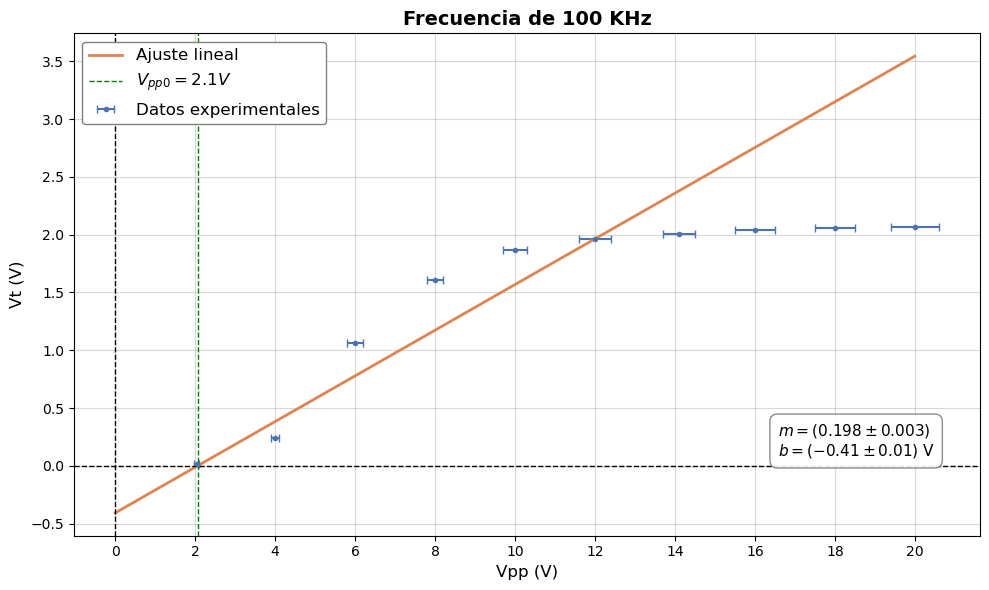

In [104]:
plt.figure(figsize=(10, 6))

plt.errorbar(
    x=mediciones["vpp"],
    y=mediciones["100 KHz"],
    xerr=mediciones["vpp_error"],
    #yerr=mediciones["vt_error"],
    fmt='.',
    capsize=3,
    label='Datos experimentales',
    color='#4C72B0'
)
# Ajuste lineal
plt.plot(x, y, color='#DD8452', label='Ajuste lineal', linewidth=2)

# Tensión de Vpp0 (intersección con el eje x)
plt.axvline(x=ajuste_lineal.iloc[4]['b'], color='green', linestyle='--', linewidth=1, label='$V_{pp0}= ' + '{0:.1f} V$'.format(ajuste_lineal.iloc[4]['b']))

# Línea Horizontal en y = 0
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Línea Vertical en x = 0
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

# 1. Definir el texto del cuadro (usando formato de LaTeX en Matplotlib)
texto_box = (
    r"$m = (0.198 \pm 0.003)$" + "\n" +
    r"$b = (-0.41 \pm 0.01)\text{ V}$"
)

# 2. Agregar la caja en la esquina inferior derecha
plt.text(
    0.95, 0.15, texto_box,          # Coordenadas relativas: (X=0.95, Y=0.05) -> abajo a la derecha
    transform=plt.gca().transAxes,  # Usa el sistema de coordenadas de la figura (0 a 1)
    fontsize=11,
    verticalalignment='bottom',
    horizontalalignment='right',
    multialignment='left',
    bbox=dict(
        boxstyle='round,pad=0.5',   # Borde redondeado
        facecolor='white',          # Fondo blanco
        edgecolor='gray',           # Borde gris
        alpha=0.9                   # Opacidad del fondo
    )
)

plt.xticks(np.arange(0, 22, 2))
plt.title('Frecuencia de 100 KHz', fontsize=14, fontweight='bold')
plt.ylabel('Vt (V)', fontsize=12)
plt.xlabel('Vpp (V)', fontsize=12)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.legend(frameon=True, fontsize=12, loc='upper left', facecolor='white', framealpha=1.0, edgecolor='gray')

# guardamos 
path_save = r".\clase1\frecuencia_100KHz.png"
plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()